
Comparing Scorecard 1 and 2 (Same Scale):

PDO Match:
  are_aligned: True
  pdo1: 144.2695
  pdo2: 144.2695
  difference: 0.0000

Baseline Match:
  are_aligned: True
  offset1: 87.1229
  offset2: 87.1229
  difference: 0.0000

Odds Alignment:
  are_aligned: True
  max_difference: 0.0000

Comparing Scorecard 1 and 3 (Different Scale):

PDO Match:
  are_aligned: True
  pdo1: 144.2695
  pdo2: 144.2695
  difference: 0.0000

Baseline Match:
  are_aligned: False
  offset1: 87.1229
  offset2: 167.1229
  difference: 80.0000

Odds Alignment:
  are_aligned: False
  max_difference: 1572864000.0000


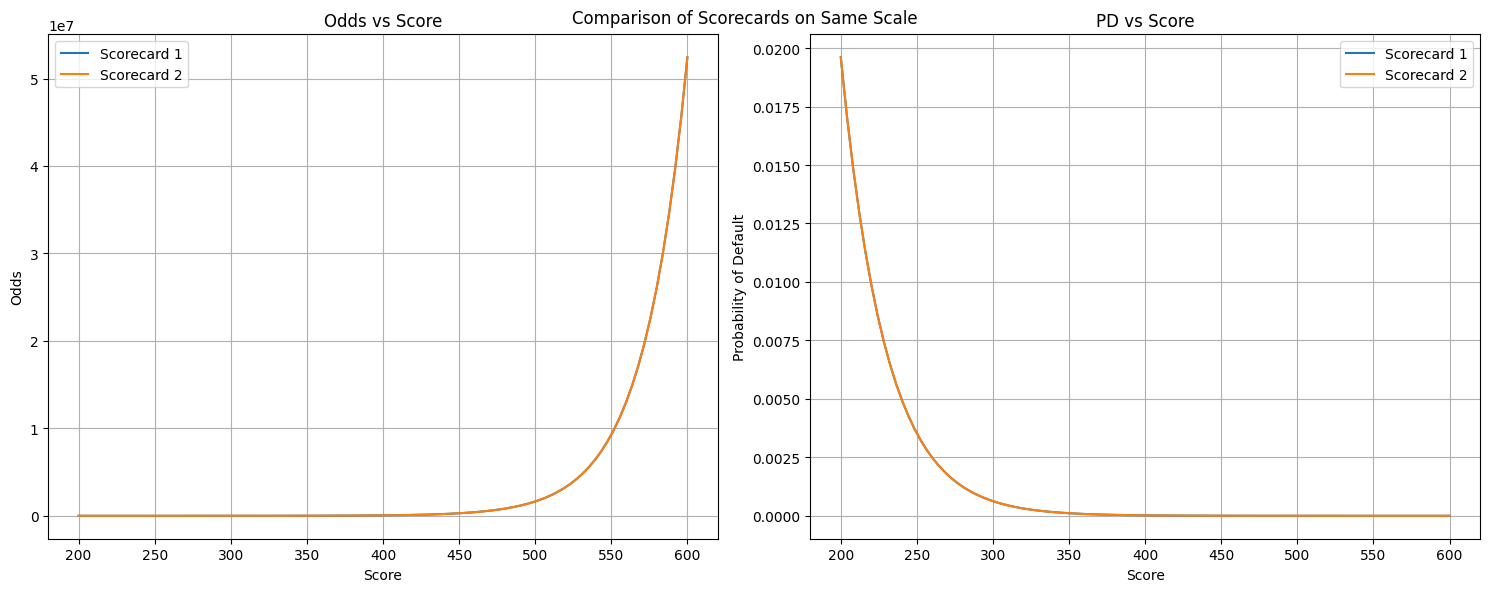

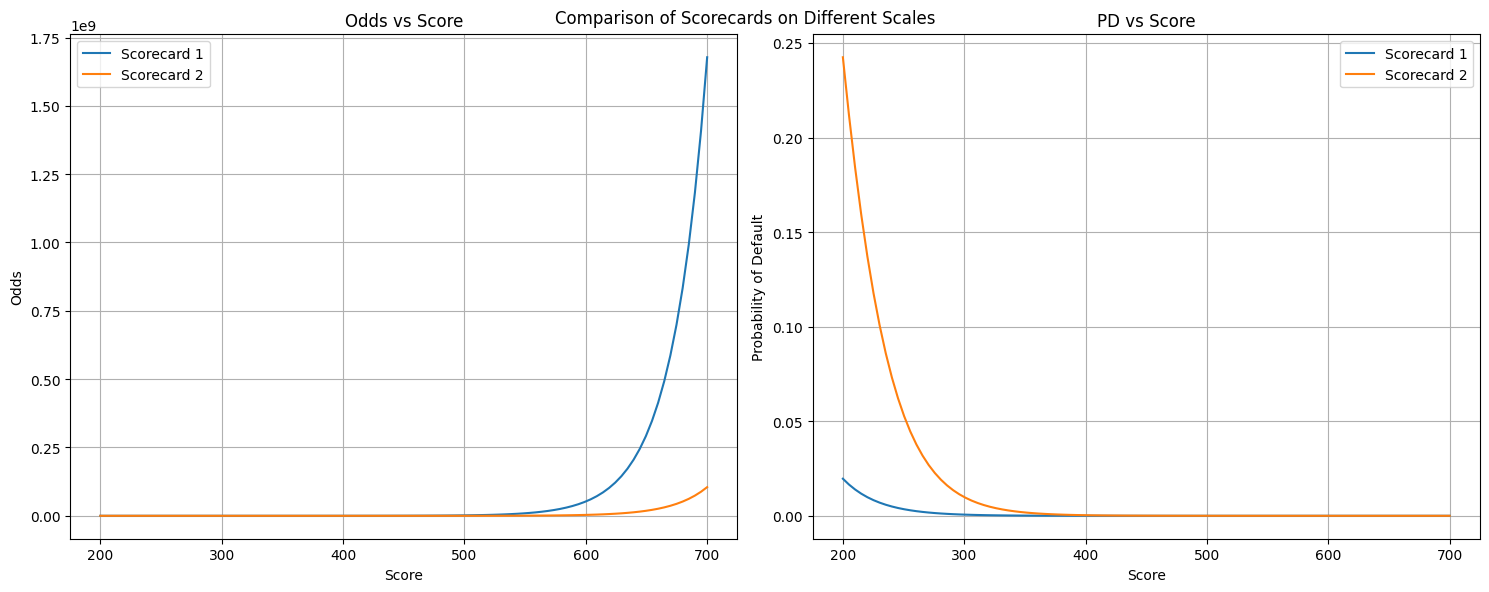

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

class ScorecardScaleAnalysis:
    def __init__(self, pdo=20, baseline_score=200, baseline_odds=50):
        self.pdo = pdo
        self.baseline_score = baseline_score
        self.baseline_odds = baseline_odds
        self.factor = pdo / np.log(2)
        self.offset = baseline_score - self.factor * np.log(baseline_odds)
        
    def check_same_scale(self, scorecard1, scorecard2):
        """
        Check if two scorecards are on the same scale
        
        Parameters:
        scorecard1, scorecard2: dictionaries containing scorecard parameters
        """
        # Check key alignment parameters
        scale_checks = {
            'PDO Match': self.check_pdo_alignment(scorecard1, scorecard2),
            'Baseline Match': self.check_baseline_alignment(scorecard1, scorecard2),
            'Odds Alignment': self.check_odds_alignment(scorecard1, scorecard2)
        }
        
        return scale_checks
    
    def check_pdo_alignment(self, card1, card2):
        """Check if PDO is consistent between scorecards"""
        score_diff1 = card1['score2'] - card1['score1']
        score_diff2 = card2['score2'] - card2['score1']
        
        odds_ratio1 = np.log(card1['odds2'] / card1['odds1'])
        odds_ratio2 = np.log(card2['odds2'] / card2['odds1'])
        
        pdo1 = score_diff1 / odds_ratio1
        pdo2 = score_diff2 / odds_ratio2
        
        return {
            'are_aligned': np.abs(pdo1 - pdo2) < 0.01,
            'pdo1': pdo1,
            'pdo2': pdo2,
            'difference': np.abs(pdo1 - pdo2)
        }
    
    def check_baseline_alignment(self, card1, card2):
        """Check if baseline scores align"""
        offset1 = card1['score1'] - self.factor * np.log(card1['odds1'])
        offset2 = card2['score1'] - self.factor * np.log(card2['odds1'])
        
        return {
            'are_aligned': np.abs(offset1 - offset2) < 0.01,
            'offset1': offset1,
            'offset2': offset2,
            'difference': np.abs(offset1 - offset2)
        }
    
    def check_odds_alignment(self, card1, card2):
        """Check if odds align at same scores"""
        test_scores = np.linspace(
            min(card1['score1'], card2['score1']),
            max(card1['score2'], card2['score2']),
            100
        )
        
        odds1 = [self.calculate_odds(score, card1) for score in test_scores]
        odds2 = [self.calculate_odds(score, card2) for score in test_scores]
        
        max_diff = max(np.abs(np.array(odds1) - np.array(odds2)))
        
        return {
            'are_aligned': max_diff < 0.01,
            'max_difference': max_diff
        }
    
    def calculate_odds(self, score, card):
        """Calculate odds for a given score using scorecard parameters"""
        factor = self.pdo / np.log(2)
        offset = card['score1'] - factor * np.log(card['odds1'])
        return np.exp((score - offset) / factor)
    
    def plot_comparison(self, scorecard1, scorecard2):
        """Plot comparison of two scorecards"""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
        
        # Generate score ranges
        score_range = np.linspace(
            min(scorecard1['score1'], scorecard2['score1']),
            max(scorecard1['score2'], scorecard2['score2']),
            100
        )
        
        # Calculate odds and PDs
        odds1 = [self.calculate_odds(score, scorecard1) for score in score_range]
        odds2 = [self.calculate_odds(score, scorecard2) for score in score_range]
        
        pd1 = [1/(1+odds) for odds in odds1]
        pd2 = [1/(1+odds) for odds in odds2]
        
        # Plot odds
        ax1.plot(score_range, odds1, label='Scorecard 1')
        ax1.plot(score_range, odds2, label='Scorecard 2')
        ax1.set_title('Odds vs Score')
        ax1.set_xlabel('Score')
        ax1.set_ylabel('Odds')
        ax1.legend()
        ax1.grid(True)
        
        # Plot PDs
        ax2.plot(score_range, pd1, label='Scorecard 1')
        ax2.plot(score_range, pd2, label='Scorecard 2')
        ax2.set_title('PD vs Score')
        ax2.set_xlabel('Score')
        ax2.set_ylabel('Probability of Default')
        ax2.legend()
        ax2.grid(True)
        
        plt.tight_layout()
        return fig

def demonstrate_scale_comparison():
    """Demonstrate comparison of scorecard scales"""
    # Initialize analyzer
    analyzer = ScorecardScaleAnalysis()
    
    # Define two scorecards
    scorecard1 = {
        'score1': 200,
        'score2': 600,
        'odds1': 50,
        'odds2': 800
    }
    
    # Same scale, different range
    scorecard2 = {
        'score1': 200,
        'score2': 500,
        'odds1': 50,
        'odds2': 400
    }
    
    # Different scale
    scorecard3 = {
        'score1': 300,
        'score2': 700,
        'odds1': 100,
        'odds2': 1600
    }
    
    # Check if scorecards are on same scale
    print("\nComparing Scorecard 1 and 2 (Same Scale):")
    print("=" * 50)
    results_same = analyzer.check_same_scale(scorecard1, scorecard2)
    print_results(results_same)
    
    print("\nComparing Scorecard 1 and 3 (Different Scale):")
    print("=" * 50)
    results_diff = analyzer.check_same_scale(scorecard1, scorecard3)
    print_results(results_diff)
    
    # Plot comparisons
    fig1 = analyzer.plot_comparison(scorecard1, scorecard2)
    plt.suptitle('Comparison of Scorecards on Same Scale')
    plt.show()
    
    fig2 = analyzer.plot_comparison(scorecard1, scorecard3)
    plt.suptitle('Comparison of Scorecards on Different Scales')
    plt.show()
    
    return results_same, results_diff

def print_results(results):
    """Print formatted results"""
    for check, result in results.items():
        print(f"\n{check}:")
        if isinstance(result, dict):
            for key, value in result.items():
                if isinstance(value, float):
                    print(f"  {key}: {value:.4f}")
                else:
                    print(f"  {key}: {value}")
        else:
            print(f"  {result}")

# Run demonstration
same_scale_results, diff_scale_results = demonstrate_scale_comparison()

def analyze_implications(same_scale_results, diff_scale_results):
    """Analyze business implications of scale differences"""
    print("\nBusiness Implications:")
    print("=" * 50)
    
    if all(result['are_aligned'] for result in same_scale_results.values()):
        print("\nScorecard 1 and 2 (Same Scale):")
        print("✓ Can be directly compared")
        print("✓ Same risk interpretation")
        print("✓ Compatible cutoff strategies")
    else:
        print("\nScorecard 1 and 2:")
        print("⚠ May need scale adjustment")
        print("⚠ Different risk interpretation")
        print("⚠ Incompatible cutoff strategies")
    
    if all(result['are_aligned'] for result in diff_scale_results.values()):
        print("\nScorecard 1 and 3:")
        print("✓ Can be directly compared")
    else:
        print("\nScorecard 1 and 3:")
        print


Scorecard Comparison Results:

Scorecard 1:
Maximum Score: 475.14
Minimum Score: 284.11
Score Range: 191.02

Scorecard 2:
Maximum Score: 510.38
Minimum Score: 298.75
Score Range: 211.63

Feature Contributions:

Scorecard 1:
              min_score  max_score    range  coefficient  contribution
feature                                                               
Credit_Score    89.0410   175.4795  86.4386          1.0        0.4525
DTI            106.4076   143.3316  36.9240          0.7        0.1933
Utilization     88.6640   156.3251  67.6611          0.8        0.3542

Scorecard 2:
              min_score  max_score     range  coefficient  contribution
feature                                                                
Credit_Score    86.1626   203.9280  117.7654          1.2        0.5565
Employment     107.8545   147.7177   39.8631          0.6        0.1884
Income         104.7320   158.7320   54.0000          0.9        0.2552


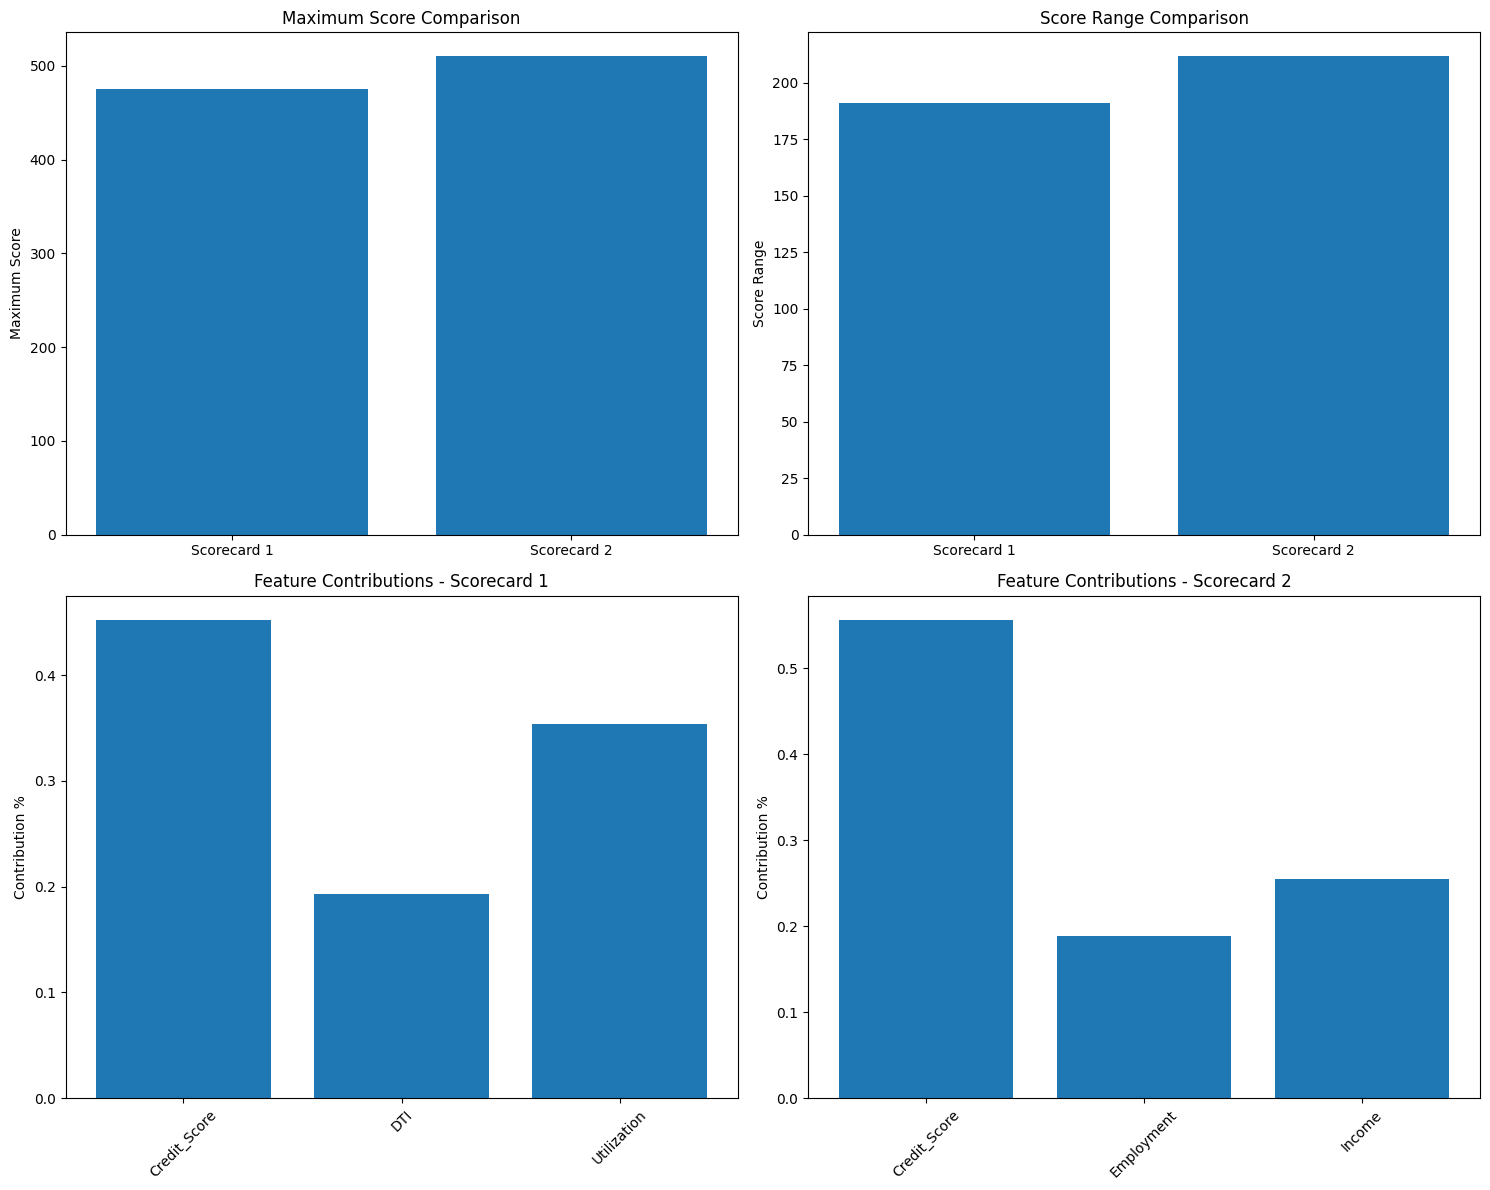

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

class ScorecardComparison:
    def __init__(self, pdo=20, baseline_score=500, baseline_odds=50):
        self.pdo = pdo
        self.baseline_score = baseline_score
        self.baseline_odds = baseline_odds
        self.factor = pdo / np.log(2)
        self.offset = baseline_score - self.factor * np.log(baseline_odds)
        
    def calculate_scorecard(self, feature_data):
        """Calculate scores for a scorecard"""
        results = feature_data.copy()
        
        # Calculate WOE and scores
        for feature in results['feature'].unique():
            mask = results['feature'] == feature
            good_total = results.loc[mask, 'good'].sum()
            bad_total = results.loc[mask, 'bad'].sum()
            
            results.loc[mask, 'good_rate'] = results.loc[mask, 'good'] / good_total
            results.loc[mask, 'bad_rate'] = results.loc[mask, 'bad'] / bad_total
            results.loc[mask, 'woe'] = np.log(results.loc[mask, 'good_rate'] / 
                                            results.loc[mask, 'bad_rate'])
        
        results['points'] = -self.factor * results['woe'] * results['coefficient']
        results['score'] = results['points'] + (self.offset / len(results['feature'].unique()))
        
        return results
    
    def compare_scorecards(self, scorecard1_data, scorecard2_data):
        """Compare two scorecards"""
        sc1_results = self.calculate_scorecard(scorecard1_data)
        sc2_results = self.calculate_scorecard(scorecard2_data)
        
        comparison = {
            'scorecard1': {
                'max_score': sc1_results.groupby('feature')['score'].max().sum(),
                'min_score': sc1_results.groupby('feature')['score'].min().sum(),
                'range': sc1_results.groupby('feature')['score'].agg(lambda x: x.max() - x.min()).sum(),
                'feature_contributions': self.analyze_feature_contributions(sc1_results),
                'results': sc1_results
            },
            'scorecard2': {
                'max_score': sc2_results.groupby('feature')['score'].max().sum(),
                'min_score': sc2_results.groupby('feature')['score'].min().sum(),
                'range': sc2_results.groupby('feature')['score'].agg(lambda x: x.max() - x.min()).sum(),
                'feature_contributions': self.analyze_feature_contributions(sc2_results),
                'results': sc2_results
            }
        }
        
        return comparison
    
    def analyze_feature_contributions(self, scorecard_results):
        """Analyze feature contributions to total score"""
        feature_stats = scorecard_results.groupby('feature').agg({
            'score': ['min', 'max', lambda x: x.max() - x.min()],
            'coefficient': 'first'
        })
        
        feature_stats.columns = ['min_score', 'max_score', 'range', 'coefficient']
        feature_stats['contribution'] = feature_stats['range'] / feature_stats['range'].sum()
        
        return feature_stats
    
    def plot_comparison(self, comparison):
        """Plot scorecard comparison"""
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        
        # Plot 1: Max Score Comparison
        max_scores = [comparison['scorecard1']['max_score'],
                     comparison['scorecard2']['max_score']]
        axes[0,0].bar(['Scorecard 1', 'Scorecard 2'], max_scores)
        axes[0,0].set_title('Maximum Score Comparison')
        axes[0,0].set_ylabel('Maximum Score')
        
        # Plot 2: Score Range Comparison
        ranges = [comparison['scorecard1']['range'],
                 comparison['scorecard2']['range']]
        axes[0,1].bar(['Scorecard 1', 'Scorecard 2'], ranges)
        axes[0,1].set_title('Score Range Comparison')
        axes[0,1].set_ylabel('Score Range')
        
        # Plot 3: Feature Contributions Scorecard 1
        fc1 = comparison['scorecard1']['feature_contributions']
        axes[1,0].bar(fc1.index, fc1['contribution'])
        axes[1,0].set_title('Feature Contributions - Scorecard 1')
        axes[1,0].set_ylabel('Contribution %')
        plt.setp(axes[1,0].xaxis.get_majorticklabels(), rotation=45)
        
        # Plot 4: Feature Contributions Scorecard 2
        fc2 = comparison['scorecard2']['feature_contributions']
        axes[1,1].bar(fc2.index, fc2['contribution'])
        axes[1,1].set_title('Feature Contributions - Scorecard 2')
        axes[1,1].set_ylabel('Contribution %')
        plt.setp(axes[1,1].xaxis.get_majorticklabels(), rotation=45)
        
        plt.tight_layout()
        return fig

def demonstrate_comparison():
    """Demonstrate scorecard comparison"""
    # Initialize comparison
    comparator = ScorecardComparison()
    
    # Example data for two scorecards
    scorecard1_data = pd.DataFrame({
        'feature': [
            'Credit_Score', 'Credit_Score', 'Credit_Score',
            'DTI', 'DTI', 'DTI',
            'Utilization', 'Utilization', 'Utilization'
        ],
        'bin': [
            '<650', '650-750', '>750',
            '<30%', '30-50%', '>50%',
            '<30%', '30-70%', '>70%'
        ],
        'good': [100, 400, 500, 400, 300, 300, 500, 300, 200],
        'bad': [80, 60, 20, 30, 60, 140, 20, 60, 150],
        'coefficient': [1.0, 1.0, 1.0, 0.7, 0.7, 0.7, 0.8, 0.8, 0.8]
    })
    
    scorecard2_data = pd.DataFrame({
        'feature': [
            'Credit_Score', 'Credit_Score', 'Credit_Score', 'Credit_Score',
            'Income', 'Income', 'Income',
            'Employment', 'Employment', 'Employment'
        ],
        'bin': [
            '<600', '600-700', '700-800', '>800',
            '<30K', '30K-60K', '>60K',
            '<1yr', '1-5yrs', '>5yrs'
        ],
        'good': [50, 300, 500, 150, 150, 400, 450, 200, 400, 400],
        'bad': [100, 80, 40, 10, 80, 60, 30, 100, 50, 20],
        'coefficient': [1.2, 1.2, 1.2, 1.2, 0.9, 0.9, 0.9, 0.6, 0.6, 0.6]
    })
    
    # Compare scorecards
    comparison = comparator.compare_scorecards(scorecard1_data, scorecard2_data)
    
    print("\nScorecard Comparison Results:")
    print("=" * 50)
    
    print("\nScorecard 1:")
    print(f"Maximum Score: {comparison['scorecard1']['max_score']:.2f}")
    print(f"Minimum Score: {comparison['scorecard1']['min_score']:.2f}")
    print(f"Score Range: {comparison['scorecard1']['range']:.2f}")
    
    print("\nScorecard 2:")
    print(f"Maximum Score: {comparison['scorecard2']['max_score']:.2f}")
    print(f"Minimum Score: {comparison['scorecard2']['min_score']:.2f}")
    print(f"Score Range: {comparison['scorecard2']['range']:.2f}")
    
    print("\nFeature Contributions:")
    print("\nScorecard 1:")
    print(comparison['scorecard1']['feature_contributions'].round(4))
    print("\nScorecard 2:")
    print(comparison['scorecard2']['feature_contributions'].round(4))
    
    # Plot comparison
    comparator.plot_comparison(comparison)
    plt.show()
    
    return comparison

# Run demonstration
comparison = demonstrate_comparison()

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

class ScorecardRiskAnalysis:
    def __init__(self, pdo=20, baseline_score=500, baseline_odds=50):
        self.pdo = pdo
        self.baseline_score = baseline_score
        self.baseline_odds = baseline_odds
        self.factor = pdo / np.log(2)
        self.offset = baseline_score - self.factor * np.log(baseline_odds)
        
    def analyze_risk_components(self, scorecard1_data, scorecard2_data):
        """Analyze risk components of two scorecards"""
        sc1 = self.calculate_risk_metrics(scorecard1_data, "Scorecard 1")
        sc2 = self.calculate_risk_metrics(scorecard2_data, "Scorecard 2")
        
        return {
            'scorecard1': sc1,
            'scorecard2': sc2,
            'comparison': self.compare_risk_profiles(sc1, sc2)
        }
    
    def calculate_risk_metrics(self, data, name):
        """Calculate risk metrics for a scorecard"""
        results = data.copy()
        
        # Calculate WOE and basic metrics
        total_good = results['good'].sum()
        total_bad = results['bad'].sum()
        results['good_rate'] = results['good'] / total_good
        results['bad_rate'] = results['bad'] / total_bad
        results['woe'] = np.log(results['good_rate'] / results['bad_rate'])
        results['points'] = -self.factor * results['woe'] * results['coefficient']
        
        metrics = {
            'name': name,
            'max_score': results.groupby('feature')['points'].sum().max() + self.offset,
            'min_score': results.groupby('feature')['points'].sum().min() + self.offset,
            'woe_range': results['woe'].max() - results['woe'].min(),
            'avg_coefficient': results['coefficient'].mean(),
            'risk_indicators': {
                'bad_rate': total_bad / (total_good + total_bad),
                'woe_distribution': results['woe'].describe(),
                'score_range': results.groupby('feature')['points'].sum().max() - 
                              results.groupby('feature')['points'].sum().min()
            }
        }
        
        return metrics
    
    def compare_risk_profiles(self, sc1, sc2):
        """Compare risk profiles of two scorecards"""
        return {
            'max_score_diff': sc1['max_score'] - sc2['max_score'],
            'risk_factors': self.analyze_risk_factors(sc1, sc2),
            'interpretation': self.interpret_differences(sc1, sc2)
        }
    
    def analyze_risk_factors(self, sc1, sc2):
        """Analyze various risk factors"""
        return {
            'coefficient_impact': {
                'difference': sc1['avg_coefficient'] - sc2['avg_coefficient'],
                'interpretation': "Higher coefficients don't necessarily mean higher risk"
            },
            'woe_range_impact': {
                'difference': sc1['woe_range'] - sc2['woe_range'],
                'interpretation': "WOE range indicates risk differentiation ability"
            },
            'score_range_impact': {
                'difference': sc1['risk_indicators']['score_range'] - 
                             sc2['risk_indicators']['score_range'],
                'interpretation': "Score range shows risk separation capability"
            }
        }
    
    def interpret_differences(self, sc1, sc2):
        """Provide interpretation of differences"""
        return {
            'max_score': "Max score difference is due to technical factors, not necessarily risk",
            'risk_assessment': "Risk should be assessed through multiple factors:",
            'key_factors': [
                "Population risk distribution",
                "Risk separation ability",
                "Feature predictiveness",
                "Model discrimination power"
            ]
        }

def demonstrate_risk_analysis():
    """Demonstrate risk analysis with examples"""
    
    # Example data for two scorecards
    scorecard1_data = pd.DataFrame({
        'feature': ['A', 'A', 'A', 'B', 'B', 'B'],
        'bin': ['1', '2', '3', '1', '2', '3'],
        'good': [100, 300, 600, 200, 400, 400],
        'bad': [50, 60, 40, 80, 60, 30],
        'coefficient': [1.0, 1.0, 1.0, 0.8, 0.8, 0.8]
    })
    
    scorecard2_data = pd.DataFrame({
        'feature': ['X', 'X', 'X', 'Y', 'Y', 'Y'],
        'bin': ['1', '2', '3', '1', '2', '3'],
        'good': [150, 400, 450, 200, 300, 500],
        'bad': [60, 70, 30, 100, 50, 20],
        'coefficient': [0.7, 0.7, 0.7, 0.9, 0.9, 0.9]
    })
    
    analyzer = ScorecardRiskAnalysis()
    analysis = analyzer.analyze_risk_components(scorecard1_data, scorecard2_data)
    
    print("\nScorecard Risk Analysis:")
    print("=" * 50)
    
    print("\nScorecard 1 Metrics:")
    print(f"Max Score: {analysis['scorecard1']['max_score']:.2f}")
    print(f"WOE Range: {analysis['scorecard1']['woe_range']:.2f}")
    print(f"Average Coefficient: {analysis['scorecard1']['avg_coefficient']:.2f}")
    
    print("\nScorecard 2 Metrics:")
    print(f"Max Score: {analysis['scorecard2']['max_score']:.2f}")
    print(f"WOE Range: {analysis['scorecard2']['woe_range']:.2f}")
    print(f"Average Coefficient: {analysis['scorecard2']['avg_coefficient']:.2f}")
    
    print("\nRisk Factor Analysis:")
    for factor, details in analysis['comparison']['risk_factors'].items():
        print(f"\n{factor}:")
        for key, value in details.items():
            print(f"  {key}: {value}")
    
    return analysis

# Run demonstration
analysis = demonstrate_risk_analysis()

def explain_misconceptions():
    """Explain common misconceptions about scorecard max scores"""
    misconceptions = {
        "Max Score = Risk Level": {
            "misconception": "Lower max score means higher risk",
            "reality": "Max score is influenced by technical factors",
            "explanation": "Same risk patterns can result in different max scores"
        },
        "Technical Factors": {
            "coefficient_scaling": "Different coefficient scales affect max score",
            "bin_structure": "Different binning affects WOE ranges",
            "feature_count": "Number of features affects score distribution"
        },
        "True Risk Indicators": {
            "population_distribution": "Actual good/bad ratios in score bands",
            "discrimination_power": "Ability to separate good/bad cases",
            "calibration": "Alignment of predicted and actual risk",
            "stability": "Consistency of risk patterns"
        }
    }
    
    print("\nCommon Misconceptions About Scorecard Max Scores:")
    print("=" * 50)
    for topic, details in misconceptions.items():
        print(f"\n{topic}:")
        for key, value in details.items():
            print(f"  {key}: {value}")

# Explain misconceptions
explain_misconceptions()


Scorecard Risk Analysis:

Scorecard 1 Metrics:
Max Score: 401.18
WOE Range: 2.01
Average Coefficient: 0.90

Scorecard 2 Metrics:
Max Score: 387.89
WOE Range: 2.53
Average Coefficient: 0.80

Risk Factor Analysis:

coefficient_impact:
  difference: 0.09999999999999998
  interpretation: Higher coefficients don't necessarily mean higher risk

woe_range_impact:
  difference: -0.5108256237659909
  interpretation: WOE range indicates risk differentiation ability

score_range_impact:
  difference: 3.36594350152383
  interpretation: Score range shows risk separation capability

Common Misconceptions About Scorecard Max Scores:

Max Score = Risk Level:
  misconception: Lower max score means higher risk
  reality: Max score is influenced by technical factors
  explanation: Same risk patterns can result in different max scores

Technical Factors:
  coefficient_scaling: Different coefficient scales affect max score
  bin_structure: Different binning affects WOE ranges
  feature_count: Number of fe

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

class ScorecardRiskAnalysis:
    def __init__(self, pdo=20, baseline_score=500, baseline_odds=50):
        self.pdo = pdo
        self.baseline_score = baseline_score
        self.baseline_odds = baseline_odds
        self.factor = pdo / np.log(2)
        self.offset = baseline_score - self.factor * np.log(baseline_odds)
        
    def analyze_risk_components(self, scorecard1_data, scorecard2_data):
        """Analyze risk components of two scorecards"""
        sc1 = self.calculate_risk_metrics(scorecard1_data, "Scorecard 1")
        sc2 = self.calculate_risk_metrics(scorecard2_data, "Scorecard 2")
        
        return {
            'scorecard1': sc1,
            'scorecard2': sc2,
            'comparison': self.compare_risk_profiles(sc1, sc2)
        }
    
    def calculate_risk_metrics(self, data, name):
        """Calculate risk metrics for a scorecard"""
        results = data.copy()
        
        # Calculate WOE and basic metrics
        total_good = results['good'].sum()
        total_bad = results['bad'].sum()
        results['good_rate'] = results['good'] / total_good
        results['bad_rate'] = results['bad'] / total_bad
        results['woe'] = np.log(results['good_rate'] / results['bad_rate'])
        results['points'] = -self.factor * results['woe'] * results['coefficient']
        
        metrics = {
            'name': name,
            'max_score': results.groupby('feature')['points'].sum().max() + self.offset,
            'min_score': results.groupby('feature')['points'].sum().min() + self.offset,
            'woe_range': results['woe'].max() - results['woe'].min(),
            'avg_coefficient': results['coefficient'].mean(),
            'risk_indicators': {
                'bad_rate': total_bad / (total_good + total_bad),
                'woe_distribution': results['woe'].describe(),
                'score_range': results.groupby('feature')['points'].sum().max() - 
                              results.groupby('feature')['points'].sum().min()
            }
        }
        
        return metrics
    
    def compare_risk_profiles(self, sc1, sc2):
        """Compare risk profiles of two scorecards"""
        return {
            'max_score_diff': sc1['max_score'] - sc2['max_score'],
            'risk_factors': self.analyze_risk_factors(sc1, sc2),
            'interpretation': self.interpret_differences(sc1, sc2)
        }
    
    def analyze_risk_factors(self, sc1, sc2):
        """Analyze various risk factors"""
        return {
            'coefficient_impact': {
                'difference': sc1['avg_coefficient'] - sc2['avg_coefficient'],
                'interpretation': "Higher coefficients don't necessarily mean higher risk"
            },
            'woe_range_impact': {
                'difference': sc1['woe_range'] - sc2['woe_range'],
                'interpretation': "WOE range indicates risk differentiation ability"
            },
            'score_range_impact': {
                'difference': sc1['risk_indicators']['score_range'] - 
                             sc2['risk_indicators']['score_range'],
                'interpretation': "Score range shows risk separation capability"
            }
        }
    
    def interpret_differences(self, sc1, sc2):
        """Provide interpretation of differences"""
        return {
            'max_score': "Max score difference is due to technical factors, not necessarily risk",
            'risk_assessment': "Risk should be assessed through multiple factors:",
            'key_factors': [
                "Population risk distribution",
                "Risk separation ability",
                "Feature predictiveness",
                "Model discrimination power"
            ]
        }

def demonstrate_risk_analysis():
    """Demonstrate risk analysis with examples"""
    
    # Example data for two scorecards
    scorecard1_data = pd.DataFrame({
        'feature': ['A', 'A', 'A', 'B', 'B', 'B'],
        'bin': ['1', '2', '3', '1', '2', '3'],
        'good': [100, 300, 600, 200, 400, 300],
        'bad': [50, 60, 40, 80, 60, 30],
        'coefficient': [1.0, 1.0, 1.0, 0.6, 0.8, 1]
    })
    
    scorecard2_data = pd.DataFrame({
        'feature': ['X', 'X', 'X', 'Y', 'Y', 'Y'],
        'bin': ['1', '2', '3', '1', '2', '3'],
        'good': [150, 400, 450, 200, 300, 500],
        'bad': [60, 70, 30, 100, 50, 20],
        'coefficient': [0.7, 0.7, 0.7, 0.9, 0.9, 0.9]
    })
    
    analyzer = ScorecardRiskAnalysis()
    analysis = analyzer.analyze_risk_components(scorecard1_data, scorecard2_data)
    
    print("\nScorecard Risk Analysis:")
    print("=" * 50)
    
    print("\nScorecard 1 Metrics:")
    print(f"Max Score: {analysis['scorecard1']['max_score']:.2f}")
    print(f"WOE Range: {analysis['scorecard1']['woe_range']:.2f}")
    print(f"Average Coefficient: {analysis['scorecard1']['avg_coefficient']:.2f}")
    
    print("\nScorecard 2 Metrics:")
    print(f"Max Score: {analysis['scorecard2']['max_score']:.2f}")
    print(f"WOE Range: {analysis['scorecard2']['woe_range']:.2f}")
    print(f"Average Coefficient: {analysis['scorecard2']['avg_coefficient']:.2f}")
    
    print("\nRisk Factor Analysis:")
    for factor, details in analysis['comparison']['risk_factors'].items():
        print(f"\n{factor}:")
        for key, value in details.items():
            print(f"  {key}: {value}")
    
    return analysis

# Run demonstration
analysis = demonstrate_risk_analysis()

def explain_misconceptions():
    """Explain common misconceptions about scorecard max scores"""
    misconceptions = {
        "Max Score = Risk Level": {
            "misconception": "Lower max score means higher risk",
            "reality": "Max score is influenced by technical factors",
            "explanation": "Same risk patterns can result in different max scores"
        },
        "Technical Factors": {
            "coefficient_scaling": "Different coefficient scales affect max score",
            "bin_structure": "Different binning affects WOE ranges",
            "feature_count": "Number of features affects score distribution"
        },
        "True Risk Indicators": {
            "population_distribution": "Actual good/bad ratios in score bands",
            "discrimination_power": "Ability to separate good/bad cases",
            "calibration": "Alignment of predicted and actual risk",
            "stability": "Consistency of risk patterns"
        }
    }
    
    print("\nCommon Misconceptions About Scorecard Max Scores:")
    print("=" * 50)
    for topic, details in misconceptions.items():
        print(f"\n{topic}:")
        for key, value in details.items():
            print(f"  {key}: {value}")

# Explain misconceptions
explain_misconceptions()


Scorecard Risk Analysis:

Scorecard 1 Metrics:
Max Score: 396.74
WOE Range: 2.01
Average Coefficient: 0.90

Scorecard 2 Metrics:
Max Score: 387.89
WOE Range: 2.53
Average Coefficient: 0.80

Risk Factor Analysis:

coefficient_impact:
  difference: 0.10000000000000009
  interpretation: Higher coefficients don't necessarily mean higher risk

woe_range_impact:
  difference: -0.5108256237659909
  interpretation: WOE range indicates risk differentiation ability

score_range_impact:
  difference: 3.8373365357369984
  interpretation: Score range shows risk separation capability

Common Misconceptions About Scorecard Max Scores:

Max Score = Risk Level:
  misconception: Lower max score means higher risk
  reality: Max score is influenced by technical factors
  explanation: Same risk patterns can result in different max scores

Technical Factors:
  coefficient_scaling: Different coefficient scales affect max score
  bin_structure: Different binning affects WOE ranges
  feature_count: Number of 

In [7]:
def analyze_max_score_difference(scorecard1, scorecard2):
    """Analyze maximum score differences"""
    difference = scorecard1['max_score'] - scorecard2['max_score']
    
    interpretation = {
        'absolute_difference': difference,
        'relative_difference': difference / scorecard1['max_score'],
        'risk_interpretation': 'Higher max score indicates lower minimum risk' if difference > 0 else 'Lower max score indicates higher minimum risk'
    }
    
    return interpretation